In [1]:
import os
import sys
import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

SCRIPT_DIR = os.path.dirname(os.path.realpath(os.path.join(os.path.dirname(os.getcwd()))))
sys.path.append(SCRIPT_DIR)

import gwfast.gwfastGlobals as glob
import gwfast.waveforms as waveforms
import gwfast.signal as signal
import gwfast.network as network
import gwfast.fisherTools as fTools
import gwfast.gwfastUtils as utils

LSC Algorithm Library (LAL) is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH
TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


## Parameters, waveform, and detector setup

In [17]:
events = {
    'Mc':np.array([30, 30]), 'eta':np.array([0.24, 0.24]), 'dL':np.array([0.5, 0.5]), 'theta':np.array([2.34, 2.34]), 'phi':np.array([5.43, 5.43]), 
    'iota':np.array([0.99*np.pi/2, 0.99*np.pi/2]), 'psi':np.array([1, 1]), 'tcoal':np.array([0, 0]), 'Phicoal':np.array([2, 2]), 
    'chiS':np.array([0.3, 0.3]), 'chiA':np.array([0.5, 0.5]), 'chi1x':np.array([0, 0]), 'chi2x':np.array([0, 0]), 'chi1y':np.array([0, 0]), 'chi2y':np.array([0, 0]), 
    'LambdaTilde':np.array([0, 0]), 'deltaLambda':np.array([0, 0]), 'ecc':np.array([0, 0]), 
    'R_orbit':np.array([20, 20]), 'M_lens':np.array([1e4, 1e4]), 'src_pos':np.array([0.062, 0.062])
}

mywf = waveforms.IMRPhenomD()

In [18]:
# Overview of lensing effects
utils.lens(events)

Image 1 parameters: {'Mc': Array([29.6679781, 29.6679781], dtype=float64), 'eta': array([0.24, 0.24]), 'dL': Array([0.5016971, 0.5016971], dtype=float64), 'theta': array([2.34, 2.34]), 'phi': array([5.43, 5.43]), 'iota': Array([1.23608536, 1.23608536], dtype=float64), 'psi': Array([1.00072637, 1.00072637], dtype=float64), 'tcoal': array([0, 0]), 'Phicoal': Array([1.95420893, 1.95420893], dtype=float64), 'chiS': array([0.3, 0.3]), 'chiA': array([0.5, 0.5]), 'chi1x': array([0, 0]), 'chi2x': array([0, 0]), 'chi1y': array([0, 0]), 'chi2y': array([0, 0]), 'LambdaTilde': array([0, 0]), 'deltaLambda': array([0, 0]), 'ecc': array([0, 0]), 'R_orbit': array([20, 20]), 'M_lens': array([10000., 10000.]), 'src_pos': array([0.062, 0.062])} 
Image 2 parameters: {'Mc': Array([28.81278797, 28.81278797], dtype=float64), 'eta': array([0.24, 0.24]), 'dL': Array([0.47319076, 0.47319076], dtype=float64), 'theta': array([2.34, 2.34]), 'phi': array([5.43, 5.43]), 'iota': Array([1.87243108, 1.87243108], dtype=

In [19]:
# Detector configurations
L1_conf = copy.deepcopy(glob.detectors).pop('L1')
L1_conf['psd_path'] = os.path.join(glob.detPath, 'observing_scenarios_paper', 'AplusDesign.txt')

H1_conf = copy.deepcopy(glob.detectors).pop('H1')
H1_conf['psd_path'] = os.path.join(glob.detPath, 'observing_scenarios_paper', 'AplusDesign.txt')

Virgo_conf = copy.deepcopy(glob.detectors).pop('Virgo')
Virgo_conf['psd_path'] =  os.path.join(glob.detPath, 'observing_scenarios_paper', 'avirgo_O5low_NEW.txt')

# Initialise the GWSignal objects
L1 = signal.GWSignal(mywf, psd_path=L1_conf['psd_path'], 
                        detector_shape=L1_conf['shape'], det_lat=L1_conf['lat'], 
                        det_long=L1_conf['long'], det_xax=L1_conf['xax'],
                        fmin=10
                        )
H1 = signal.GWSignal(mywf, psd_path=H1_conf['psd_path'], 
                        detector_shape=H1_conf['shape'], det_lat=H1_conf['lat'], 
                        det_long=H1_conf['long'], det_xax=H1_conf['xax'],
                        fmin=10
                        )
Virgo = signal.GWSignal(mywf, psd_path=Virgo_conf['psd_path'], 
                        detector_shape=Virgo_conf['shape'], det_lat=Virgo_conf['lat'], 
                        det_long=Virgo_conf['long'], det_xax=Virgo_conf['xax'],
                        fmin=10
                        )

mySignals = {'L1':L1, 'H1':H1, 'Virgo':Virgo}
myNet = network.DetNet(mySignals)

Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/AplusDesign.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8
Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/AplusDesign.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8
Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/avirgo_O5low_NEW.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8


In [20]:
# Select event
ev = 0

## Strain

In [21]:
# This is the order of parameters in GWStrain
strain_parameters = ['Mc', 'eta', 'dL', 'theta', 'phi', 'iota', 'psi', 
                     'tcoal', 'Phicoal', 'chiS', 'chiA', 'chi1x', 'chi2x', 'chi1y', 'chi2y', 
                     'LambdaTilde', 'deltaLambda', 'ecc']
# Add the lensed parameters as well
strain_parameters += ['R_orbit', 'M_lens', 'src_pos']

# Waveform metadata
sampling_frequency = 1024.  # Hz
duration = 8.  # s

minimum_frequency = 10.  # Hz
## This maximum frequency need not equal to fs/2
maximum_frequency = sampling_frequency / 2 

# This procedure to create coupled time and freq arrays is borrowed from Bilby
N_samples = int(np.round(duration * sampling_frequency))
N_freq_bins = int(np.round(N_samples / 2) + 1)
freq_array = np.linspace(0, sampling_frequency / 2, N_freq_bins)
time_array = np.linspace(0, duration - 1 / sampling_frequency, N_samples)

FD_strain_lensed = np.zeros_like(freq_array, dtype='complex128')
FD_strain_unlensed = np.zeros_like(freq_array, dtype='complex128')

freq_mask = (freq_array > minimum_frequency) * (freq_array < maximum_frequency)
masked_freq_arr = freq_array[freq_mask]

FD_strain_lensed[freq_mask] = \
    L1.GWstrain(masked_freq_arr, *[events[key][ev] for key in strain_parameters], 
                use_lensing=True)
FD_strain_unlensed[freq_mask] = \
    L1.GWstrain(masked_freq_arr, *[events[key][ev] for key in strain_parameters], 
                use_lensing=False)

TD_strain_lensed = np.fft.irfft(FD_strain_lensed)
TD_strain_unlensed = np.fft.irfft(FD_strain_unlensed)

# # Wrap ringdown to the end
# # TODO: Need to check how does GWstrain define the peak time
post_merger_time = -0.05
n_index = int(post_merger_time * sampling_frequency)
TD_strain_lensed = np.roll(TD_strain_lensed, n_index)
TD_strain_unlensed = np.roll(TD_strain_unlensed, n_index)

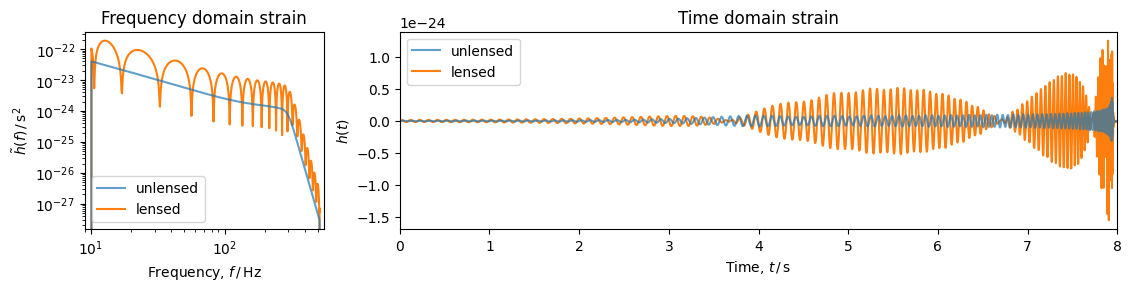

In [22]:
scale = 0.7
fig, axes = plt.subplots(1, 2, figsize=(16*scale, 4*scale),
                        width_ratios=(1, 3), constrained_layout=True)

ax = axes[0]
ax.loglog(freq_array, np.abs(FD_strain_unlensed), 
          alpha=0.7, label='unlensed')
ax.loglog(freq_array, np.abs(FD_strain_lensed), 
          label='lensed', zorder=1)
ax.set_title('Frequency domain strain')
ax.set_xlabel(r'Frequency, $f\,/\,{\rm Hz}$')
ax.set_ylabel(r'$\tilde{h}(f)\,/\,{\rm s}^2$')
ax.set_xlim(9, 550)

ax = axes[1]
ax.plot(time_array, TD_strain_unlensed, 
        alpha=0.7, label='unlensed')
ax.plot(time_array, TD_strain_lensed, 
        label='lensed', zorder=1)
ax.set_title('Time domain strain')
ax.set_xlabel(r'Time, $t\,/\,{\rm s}$')
ax.set_ylabel(r'$h(t)$')
ax.set_xlim(0.0, 8.0)

for ax in axes:
    ax.legend()

fig.savefig('8s_lensed_vs_unlensed.png', dpi=300)

**N.B.**

With low mass binary with a low starting frequency, like 10 Hz here, one must choose a duration that is sufficiently long, in this case, more than 8s. 

Otherwise, the signal will overlap with itself, this is because the waveform is generated in Fourier domain, where there is no information about the duration of the signal. 

Below is an example of what would happen with a duration that is too short:

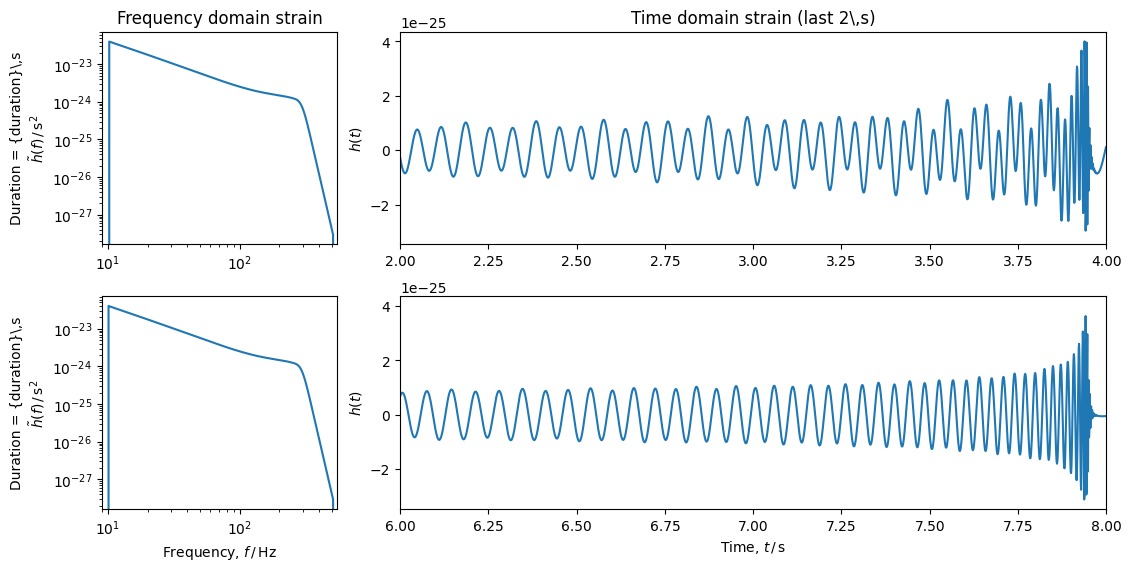

In [23]:
scale = 0.7
fig, Axes = plt.subplots(2, 2, figsize=(16*scale, 4 * 2*scale),
                        width_ratios=(1, 3), constrained_layout=True,
                        sharey='col')
    
for row, duration in enumerate((4, 8)):
    axes = Axes[row, :]
    N_samples = int(np.round(duration * sampling_frequency))
    N_freq_bins = int(np.round(N_samples / 2) + 1)
    freq_array = np.linspace(0, sampling_frequency / 2, N_freq_bins)
    time_array = np.linspace(0, duration - 1 / sampling_frequency, N_samples)
    
    FD_strain_lensed = np.zeros_like(freq_array, dtype='complex128')
    FD_strain_unlensed = np.zeros_like(freq_array, dtype='complex128')
    
    freq_mask = (freq_array > minimum_frequency) * (freq_array < maximum_frequency)
    masked_freq_arr = freq_array[freq_mask]
    
    FD_strain_unlensed[freq_mask] = \
        L1.GWstrain(masked_freq_arr, *[events[key][0] for key in strain_parameters], 
                    use_lensing=False)
    
    TD_strain_lensed = np.fft.irfft(FD_strain_lensed)
    TD_strain_unlensed = np.fft.irfft(FD_strain_unlensed)
    
    # # Wrap ringdown to the end
    # # TODO: Need to check how does GWstrain define the peak time
    post_merger_time = -0.05
    n_index = int(post_merger_time * sampling_frequency)
    TD_strain_unlensed = np.roll(TD_strain_unlensed, n_index)

    ax = axes[0]
    ax.loglog(freq_array, np.abs(FD_strain_unlensed))
    ax.set_ylabel(r'Duration = {duration}\,s' +"\n"+ r'$\tilde{h}(f)\,/\,{\rm s}^2$')
    ax.set_xlim(9, 550)
    
    ax = axes[1]
    ax.plot(time_array, TD_strain_unlensed)
    ax.set_ylabel(r'$h(t)$')

    if row == 0:
        axes[0].set_title('Frequency domain strain')    
        axes[1].set_title(r'Time domain strain (last 2\,s)')    
        axes[1].set_xlim(2., 4.)
    elif row == 1:
        axes[0].set_xlabel(r'Frequency, $f\,/\,{\rm Hz}$')
        axes[1].set_xlabel(r'Time, $t\,/\,{\rm s}$')
        axes[1].set_xlim(6., 8.)

fig.savefig('wrapping_effect_4s_vs_8s.png', dpi=300)

Notice that the FD strains have virtually no difference. The only difference is in the `delta_f`, which cannot be seen from the plot alone.

But in the time domain, one can clearly see that the waveform on top looks very different from that below. 
This is happening because the long tail is way beyond 4s (as shown from the previous plot).
If we now force the signal to be only 4s long, then this tail will have to wrap onto the itself.
Therefore producing extra interferences and wonky waveforms.

## SNR

In [24]:
mySNR = myNet.SNR(events, use_lensing=True, return_all=True)
mySNR_nolens = myNet.SNR(events, return_all=True)
print("SNR with lensing:", mySNR)
print("SNR without lensing:", mySNR_nolens)

Adding chi1z, chi2z from chiS, chiA
SNR with lensing: {'L1': Array([31.71210304, 31.71210304], dtype=float64), 'H1': Array([25.07949819, 25.07949819], dtype=float64), 'Virgo': Array([5.41272992, 5.41272992], dtype=float64), 'net': array([40.79137597, 40.79137597])}
SNR without lensing: {'L1': Array([38.24837814, 38.24837814], dtype=float64), 'H1': Array([36.00715504, 36.00715504], dtype=float64), 'Virgo': Array([14.54333284, 14.54333284], dtype=float64), 'net': array([54.50653332, 54.50653332])}


## Fisher

In [10]:
# Fisher matrix (3-detector network) with lensing
FisherMatrsNet = myNet.FisherMatr(events, use_lensing=True)
# Group internal and external parameters together
order = [0, 1, 7, 8, 9, 10, 11, 12, 13, 2, 3, 4, 5, 6]
FisherMatrsNet = FisherMatrsNet[np.ix_(order, order)]
param_labels = (r'${\cal M}$', r'$\eta$', r'$t_{\rm c}$', r'$\phi_{\rm c}$',
    r'$\chi_{S}$', r'$\chi_{A}$', r'$R_{\rm orb}$', r'$M_{\rm L}$', r'$y$',
    r'$D_{\rm L}$', r'$\alpha$', r'$\delta$', r'$\iota$', r'$\psi$'
)

Computing Fisher for L1...
Computing derivatives...
Computing Fisher for H1...
Computing derivatives...
Computing Fisher for Virgo...
Computing derivatives...
Done.


In [11]:
FisherMatrsNet[:,3,0]

array([ 3.90180497e+04,  1.49224785e+06, -2.58134299e+06,  3.91176195e+03,
       -1.46769939e+05, -6.81720246e+04, -2.82070843e+03, -3.68157332e+00,
        2.10325356e+06,  2.67608892e-05, -4.12776077e+04, -2.18630650e+04,
        1.06414418e+07, -1.55693350e+03])

Text(0.5, 1.0, 'Rescaled Fisher matrix')

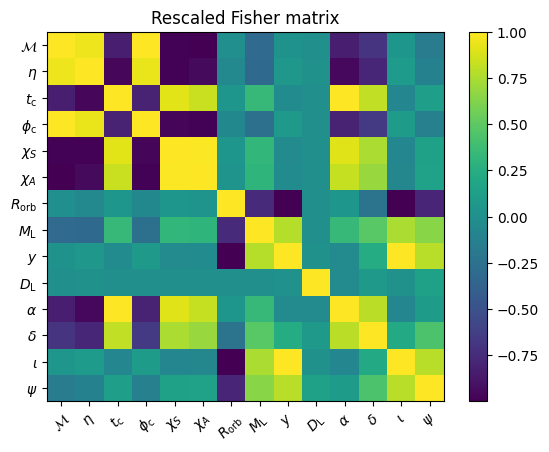

In [12]:
# Plot Fisher matrix
matrix = FisherMatrsNet[:, :, ev]
sqrt_diagonal = np.sqrt(np.diag(matrix))
sqrt_diagonal_inv = np.diag(1 / sqrt_diagonal)
matrix_rescaled = sqrt_diagonal_inv @ matrix @ sqrt_diagonal_inv

fig, ax = plt.subplots()
x = np.arange(0, matrix_rescaled.shape[0]+1, 1)
y = np.arange(matrix_rescaled.shape[1], -1, -1)
im = ax.pcolormesh(x, y, matrix_rescaled)
fig.colorbar(im)
ax.set_xticks(np.arange(0, matrix_rescaled.shape[0], 1)+0.5, param_labels, rotation=45)
ax.set_yticks(np.arange(matrix_rescaled.shape[1], 0, -1)-0.5, param_labels)
ax.set_title('Rescaled Fisher matrix')

In [13]:
# Get covariance matrix and inversion error
Cov, ie = fTools.CovMatr(FisherMatrsNet)

std = np.sqrt(np.diag(Cov[:,:,ev]))
params = ['Mc', 'eta', 'tcoal', 'Phicoal', 'chiS', 'chiA', 'R_orbit', 'M_lens', 'src_pos', 'dL', 'alpha', 'delta', 'iota', 'psi']
print("Standard deviations:", ['{}: {:.6f}'.format(params[i], std[i]) for i in range(len(params))])
print("Inversion error:", ie)

Standard deviations: ['Mc: 0.185043', 'eta: 0.011650', 'tcoal: 0.007305', 'Phicoal: 0.716861', 'chiS: 0.319591', 'chiA: 0.642622', 'R_orbit: 3.866101', 'M_lens: 1820.183191', 'src_pos: 0.011288', 'dL: 0.214281', 'alpha: 0.012967', 'delta: 0.003966', 'iota: 0.002986', 'psi: 0.018277']
Inversion error: [0.00181984 0.00866315]


In [14]:
# Calculate fractional uncertainty
# For angular parameters, this is calculated as std / length of interval of possible values (2pi for Phicoal, alpha and psi, pi for delta and iota)
# For normalized parameters, this is taken as std (eta, chiS, chiA, src_pos)
# For all other parameters, this is calculated as std / injected value

scale_factor = [events['Mc'][ev], 1, events['tcoal'][ev], 2*np.pi, 1, 1, 
                events['R_orbit'][ev], events['M_lens'][ev], 1, 
                events['dL'][ev], 2*np.pi, np.pi, np.pi, 2*np.pi]
fractional_uncertainty = std / scale_factor
print("Fractional uncertainties:", ['{}: {:.6f}'.format(params[i], fractional_uncertainty[i]) for i in range(len(params))])

Fractional uncertainties: ['Mc: 0.006168', 'eta: 0.011650', 'tcoal: inf', 'Phicoal: 0.114092', 'chiS: 0.319591', 'chiA: 0.642622', 'R_orbit: 0.193305', 'M_lens: 0.182018', 'src_pos: 0.011288', 'dL: 0.107140', 'alpha: 0.002064', 'delta: 0.001263', 'iota: 0.000950', 'psi: 0.002909']


/var/folders/b4/hg5l8r9915b4cr385qb8sfdw0000gn/T/ipykernel_17259/2121498467.py:9: RuntimeWarning: divide by zero encountered in divide
  fractional_uncertainty = std / scale_factor


### Correlation matrix

Text(0.5, 1.0, 'Correlation matrix')

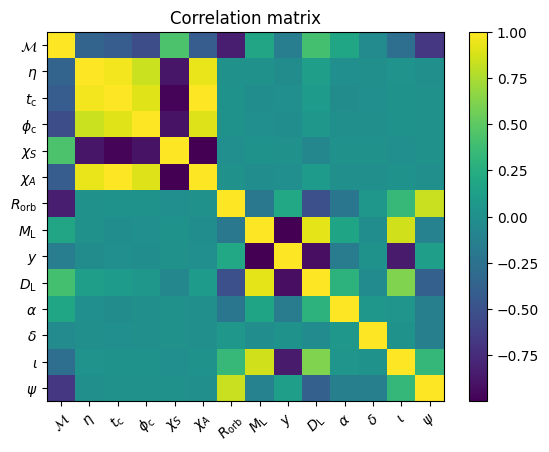

In [15]:
# Plot correlation coefficients
matrix = Cov[:, :, ev]
sqrt_diagonal = np.sqrt(np.diag(matrix))
sqrt_diagonal_inv = np.diag(1 / sqrt_diagonal)
matrix_rescaled = sqrt_diagonal_inv @ matrix @ sqrt_diagonal_inv

param_labels = (r'${\cal M}$', r'$\eta$', r'$t_{\rm c}$', r'$\phi_{\rm c}$',
    r'$\chi_{S}$', r'$\chi_{A}$', r'$R_{\rm orb}$', r'$M_{\rm L}$', r'$y$',
    r'$D_{\rm L}$', r'$\alpha$', r'$\delta$', r'$\iota$', r'$\psi$'
)
fig, ax = plt.subplots()
x = np.arange(0, matrix_rescaled.shape[0]+1, 1)
y = np.arange(matrix_rescaled.shape[1], -1, -1)
im = ax.pcolormesh(x, y, matrix_rescaled)
fig.colorbar(im)
ax.set_xticks(np.arange(0, matrix_rescaled.shape[0], 1)+0.5, param_labels, rotation=45)
ax.set_yticks(np.arange(matrix_rescaled.shape[1], 0, -1)-0.5, param_labels)
ax.set_title('Correlation matrix')

### Corner plot

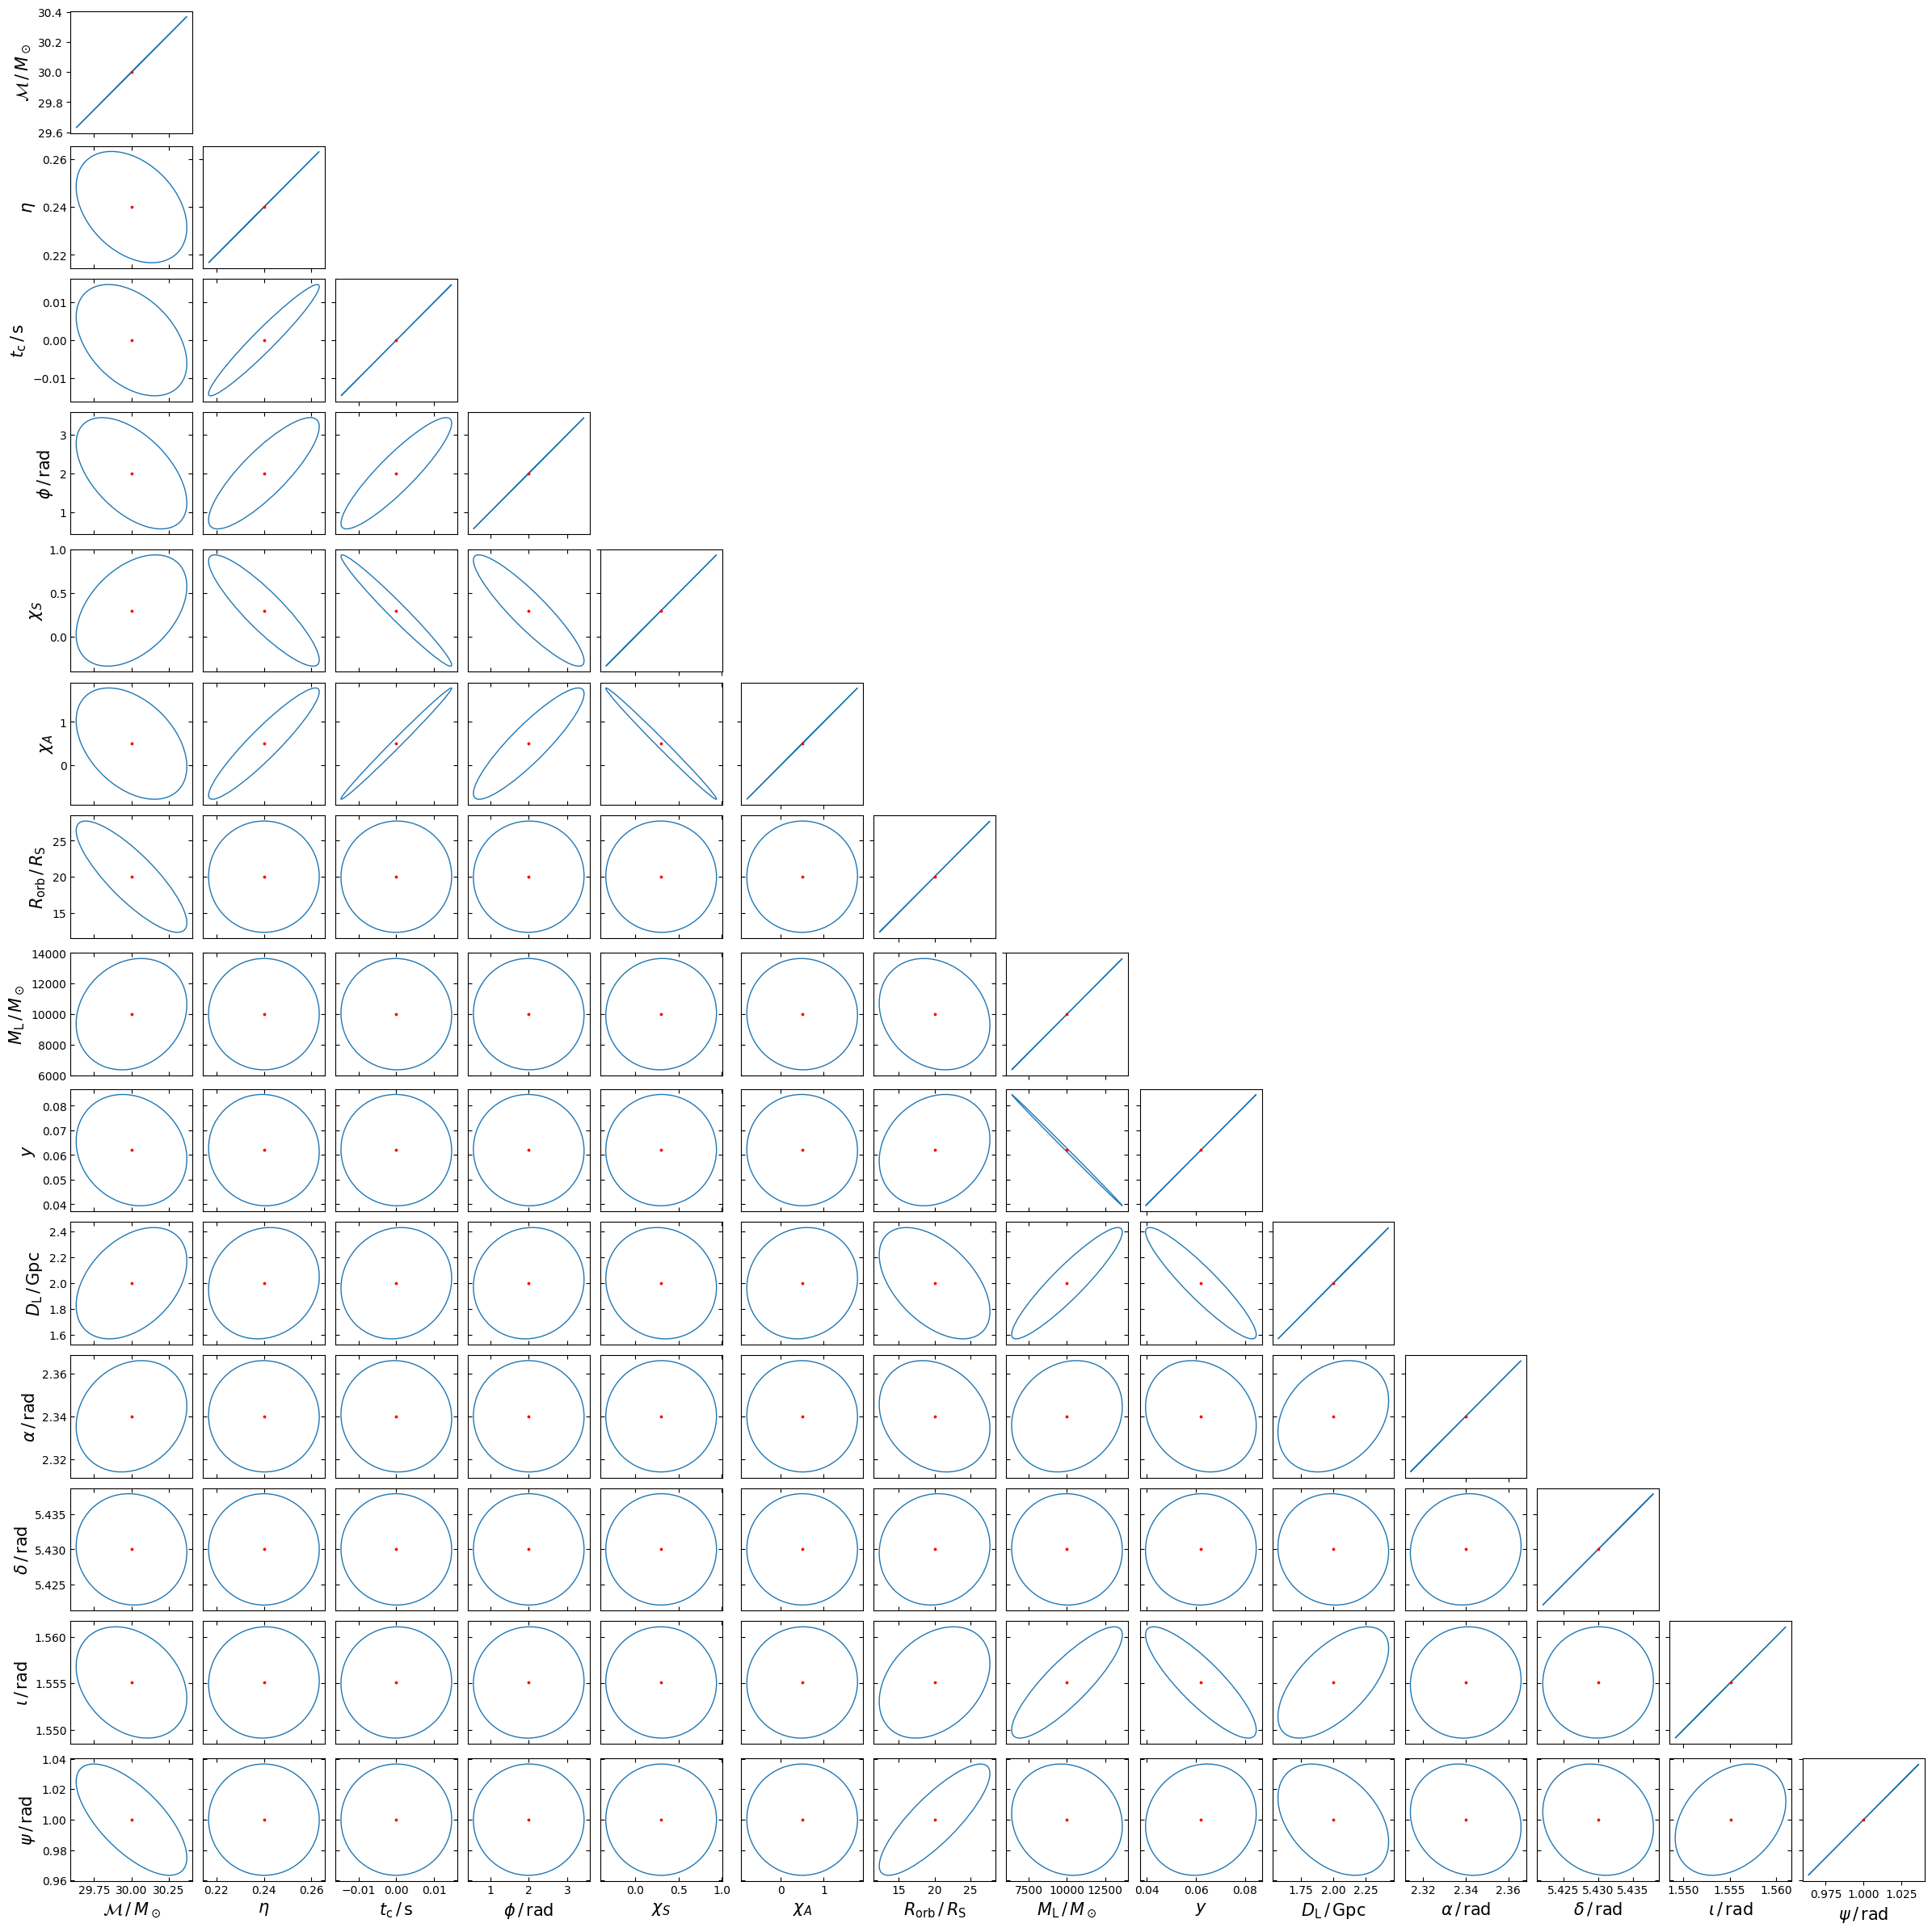

In [16]:
params = ('Mc', 'eta', 'tcoal', 'Phicoal', 'chiS', 'chiA', 'R_orbit', 'M_lens', 'src_pos', 'dL', 'theta', 'phi', 'iota', 'psi')
# We rearranged the list of parameters, so the indices needs to be updated accordingly
indices = np.arange(0, 14)

labels = {
    'Mc': r'${\cal M}\,/\,M_\odot$',
    'eta': r'$\eta$',
    'dL': r'$D_{\rm L}\,/\,{\rm Gpc}$',
    'theta': r'$\alpha\,/\,{\rm rad}$',
    'phi': r'$\delta\,/\,{\rm rad}$',
    'iota': r'$\iota\,/\,{\rm rad}$',
    'psi': r'$\psi\,/\,{\rm rad}$',
    'tcoal': r'$t_{\rm c}\,/\,{\rm s}$',
    'Phicoal': r'$\phi\,/\,{\rm rad}$',
    'chiS': r'$\chi_{S}$',
    'chiA': r'$\chi_{A}$',
    'R_orbit': r'$R_{\rm orb}\,/\,R_{\rm S}$',
    'M_lens': r'$M_{\rm L}\,/\,M_\odot$',
    'src_pos': r'$y$'
}

event = {key: val[0] for key, val in events.items()}

fig = fTools.plot_corners(
    Cov[:, :, ev], params, indices, 
    event=event, labels=labels, color='C0'
)

fig.savefig('test_Fisher_matrix.png', dpi=200)